In [3]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")

In [4]:
# Step 1 - Install (run once)
!pip install mysql-connector-python


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Step 1 - Install in the SAME environment as Jupyter
import sys
!{sys.executable} -m pip install mysql-connector-python

   ---------------------------------------- 0.0/18.2 MB ? eta -:--:--
   -- ------------------------------------- 1.3/18.2 MB 11.8 MB/s eta 0:00:02
   ------- -------------------------------- 3.4/18.2 MB 10.3 MB/s eta 0:00:02
   -------- ------------------------------- 3.7/18.2 MB 6.7 MB/s eta 0:00:03
   ---------- ----------------------------- 5.0/18.2 MB 6.6 MB/s eta 0:00:02
   ------------- -------------------------- 6.0/18.2 MB 6.4 MB/s eta 0:00:02
   ---------------- ----------------------- 7.3/18.2 MB 6.2 MB/s eta 0:00:02
   ------------------ --------------------- 8.4/18.2 MB 6.1 MB/s eta 0:00:02
   -------------------- ------------------- 9.4/18.2 MB 6.0 MB/s eta 0:00:02
   ----------------------- ---------------- 10.7/18.2 MB 6.0 MB/s eta 0:00:02
   ------------------------- -------------- 11.8/18.2 MB 6.0 MB/s eta 0:00:02
   --------------------------- ------------ 12.6/18.2 MB 5.8 MB/s eta 0:00:01
   -------------------------------- ------- 14.7/18.2 MB 6.0 MB/s eta 0:00:01



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\AYAN\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [5]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    port=3306,
    user="root",
    password="Ayan@1998",  # ⚠️ fill in your MySQL root password
    database="commodities_supply"
)

cursor = conn.cursor()
print("Connected! ✅")

Connected! ✅


In [6]:
cursor.execute("SHOW TABLES")
for table in cursor.fetchall():
    print(table)

('category',)
('commodities_info',)
('customer_info',)
('department',)
('orders',)
('orders_items',)
('price_detail',)
('product_info',)
('region',)


In [5]:
cursor.execute("SHOW TABLES")
for table in cursor.fetchall():
    print(table)

('category',)
('commodities_info',)
('customer_info',)
('department',)
('orders',)
('orders_items',)
('price_detail',)
('product_info',)
('region',)


In [7]:
import pandas as pd

# pick any table from your list
cursor.execute("SELECT * FROM category")
df_category = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])

cursor.execute("SELECT * FROM commodities_info")
df_commodities = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])

cursor.execute("SELECT * FROM customer_info")
df_customers = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])

cursor.execute("SELECT * FROM orders")
df_orders = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])

cursor.execute("SELECT * FROM orders_items")
df_order_items = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])

cursor.execute("SELECT * FROM price_detail")
df_price = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])

cursor.execute("SELECT * FROM product_info")
df_products = pd.DataFrame(cursor.fetchall(), columns=[col[0] for col in cursor.description])

# Preview one
df_orders.head()

,Order_Id,Type,Real_Shipping_Days,Scheduled_Shipping_Days,Customer_Id,Order_City,Order_Date,Order_State,Order_Status,Shipping_Mode
0,20337,DEBIT,3,4,8838,Kolhapur,23-10-2018,Maharashtra,ON_HOLD,Standard Class
1,20338,PAYMENT,4,4,5231,Kolhapur,23-10-2018,Maharashtra,PENDING_PAYMENT,Standard Class
2,20346,DEBIT,2,2,6365,Bareilly,23-10-2018,Uttar Pradesh,COMPLETE,Second Class
3,20361,TRANSFER,2,2,5217,Raipur,24-10-2018,Rajasthan,PENDING,Second Class
4,20363,TRANSFER,4,2,7667,Raipur,24-10-2018,Rajasthan,PENDING,Second Class


In [8]:
for table in ['category','commodities_info','customer_info','department',
              'orders','orders_items','price_detail','product_info','region']:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    count = cursor.fetchone()[0]
    cursor.execute(f"DESCRIBE {table}")
    cols = [row[0] for row in cursor.fetchall()]
    print(f"\n📋 {table} — {count} rows")
    print(f"   Columns: {cols}")


📋 category — 51 rows
   Columns: ['Category_Id', 'Category_Name']

📋 commodities_info — 99 rows
   Columns: ['Id', 'Commodity', 'Variety', 'Unit', 'Category']

📋 customer_info — 4461 rows
   Columns: ['Customer_Id', 'City', 'First_Name', 'Last_Name', 'Segment', 'State', 'Street', 'Zipcode']

📋 department — 12 rows
   Columns: ['Department_Id', 'Department_Name']

📋 orders — 2152 rows
   Columns: ['Order_Id', 'Type', 'Real_Shipping_Days', 'Scheduled_Shipping_Days', 'Customer_Id', 'Order_City', 'Order_Date', 'Order_State', 'Order_Status', 'Shipping_Mode']

📋 orders_items — 4783 rows
   Columns: ['Order_Item_Id', 'Order_Id', 'Item_Id', 'Quantity', 'Sales']

📋 price_detail — 90346 rows
   Columns: ['Id', 'Region_Id', 'Commodity_Id', 'Date', 'Retail_Price']

📋 product_info — 72 rows
   Columns: ['Product_Id', 'Product_Name', 'Category_Id', 'Department_Id', 'Product_Price']

📋 region — 77 rows
   Columns: ['Id', 'City', 'State']


In [9]:
import sys
!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\AYAN\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [10]:
# Fix - recreate the column
df_orders['Order_Date'] = pd.to_datetime(df_orders['Order_Date'], dayfirst=True)
df_orders['Shipping_Delay'] = df_orders['Real_Shipping_Days'] - df_orders['Scheduled_Shipping_Days']

# Verify it exists
print(df_orders.columns.tolist())
print(df_orders['Shipping_Delay'].head())

['Order_Id', 'Type', 'Real_Shipping_Days', 'Scheduled_Shipping_Days', 'Customer_Id', 'Order_City', 'Order_Date', 'Order_State', 'Order_Status', 'Shipping_Mode', 'Shipping_Delay']
0   -1
1    0
2    0
3    0
4    2
Name: Shipping_Delay, dtype: int64


In [12]:
# Check which table has Sales
df_items = pd.read_sql("SELECT * FROM orders_items LIMIT 5", conn)
print(df_items.columns.tolist())

df_price = pd.read_sql("SELECT * FROM price_detail LIMIT 5", conn)
print(df_price.columns.tolist())

['Order_Item_Id', 'Order_Id', 'Item_Id', 'Quantity', 'Sales']
['Id', 'Region_Id', 'Commodity_Id', 'Date', 'Retail_Price']


In [13]:
df_orders = pd.read_sql("SELECT * FROM orders", conn)
df_items = pd.read_sql("SELECT * FROM orders_items", conn)

# Join orders with items
df = pd.merge(df_orders, df_items, on='Order_Id', how='inner')

# Basic cleaning
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Shipping_Delay'] = df['Real_Shipping_Days'] - df['Scheduled_Shipping_Days']

print(df.shape)
print(df.columns.tolist())
df.head()

(4783, 15)
['Order_Id', 'Type', 'Real_Shipping_Days', 'Scheduled_Shipping_Days', 'Customer_Id', 'Order_City', 'Order_Date', 'Order_State', 'Order_Status', 'Shipping_Mode', 'Order_Item_Id', 'Item_Id', 'Quantity', 'Sales', 'Shipping_Delay']


,Order_Id,Type,Real_Shipping_Days,Scheduled_Shipping_Days,Customer_Id,Order_City,Order_Date,Order_State,Order_Status,Shipping_Mode,Order_Item_Id,Item_Id,Quantity,Sales,Shipping_Delay
0,20337,DEBIT,3,4,8838,Kolhapur,2018-10-23,Maharashtra,ON_HOLD,Standard Class,50787,1004,1,399.98,-1
1,20338,PAYMENT,4,4,5231,Kolhapur,2018-10-23,Maharashtra,PENDING_PAYMENT,Standard Class,50791,365,2,119.98,0
2,20338,PAYMENT,4,4,5231,Kolhapur,2018-10-23,Maharashtra,PENDING_PAYMENT,Standard Class,50788,502,2,100.00,0
3,20338,PAYMENT,4,4,5231,Kolhapur,2018-10-23,Maharashtra,PENDING_PAYMENT,Standard Class,50789,191,4,399.96,0
4,20338,PAYMENT,4,4,5231,Kolhapur,2018-10-23,Maharashtra,PENDING_PAYMENT,Standard Class,50790,365,4,239.96,0


In [ ]:
# Univariate — Code 1: Distribution of Sales

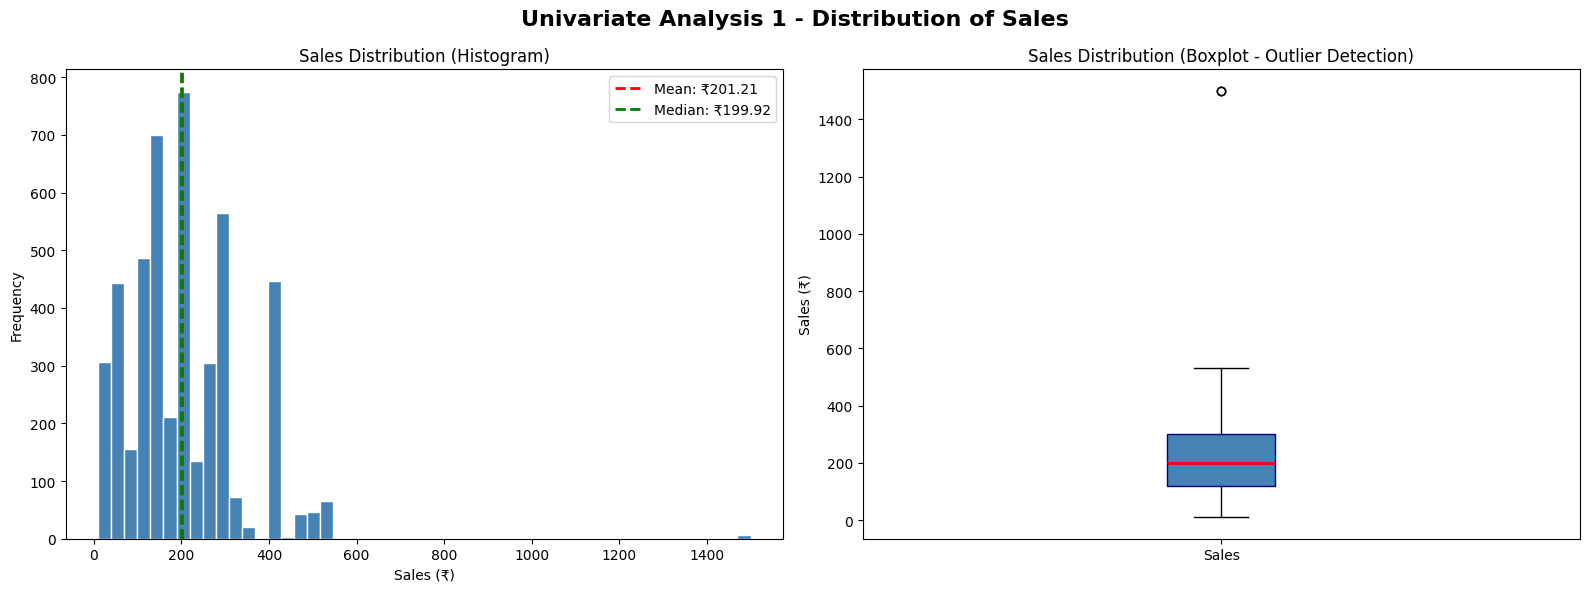

📊 SALES SUMMARY STATISTICS
count    4783.00
mean      201.21
std       129.94
min         9.99
25%       119.97
50%       199.92
75%       299.95
max      1500.00
Name: Sales, dtype: float64

Skewness : 1.92
Kurtosis : 13.64

📌 UNIVARIATE 1 - DISTRIBUTION OF SALES FINDINGS
BUSINESS PROBLEM : What is the overall sales pattern and 
                   are there any unusually high-value orders?

1. AVERAGE ORDER  : The mean sales value reveals the typical
                    spending per order item.

2. SKEWNESS       : If skewness > 1, distribution is right-skewed —
                    majority of orders are low value but a few 
                    high-value orders pull the mean upward.

3. OUTLIERS       : Boxplot shows high-value outliers (dots above 
                    whisker) — these are premium/bulk orders that 
                    contribute disproportionately to revenue.

4. MEDIAN vs MEAN : If mean >> median, revenue is concentrated in 
                    fewer large orders — 

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Univariate Analysis 1 - Distribution of Sales", 
             fontsize=16, fontweight='bold')

# --- 1. Histogram of Sales ---
axes[0].hist(df['Sales'].dropna(), bins=50, 
             color='steelblue', edgecolor='white')
axes[0].axvline(df['Sales'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: ₹{df['Sales'].mean():.2f}")
axes[0].axvline(df['Sales'].median(), color='green', linestyle='--', linewidth=2,
                label=f"Median: ₹{df['Sales'].median():.2f}")
axes[0].set_title("Sales Distribution (Histogram)")
axes[0].set_xlabel("Sales (₹)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# --- 2. Boxplot to detect outliers ---
axes[1].boxplot(df['Sales'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', color='orange', alpha=0.4))
axes[1].set_title("Sales Distribution (Boxplot - Outlier Detection)")
axes[1].set_ylabel("Sales (₹)")
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Sales'])

plt.tight_layout()
plt.savefig("univariate_sales_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Summary Stats ---
print("=" * 50)
print("📊 SALES SUMMARY STATISTICS")
print("=" * 50)
print(df['Sales'].describe().round(2))
print(f"\nSkewness : {df['Sales'].skew():.2f}")
print(f"Kurtosis : {df['Sales'].kurt():.2f}")

print("""
=======================================================
📌 UNIVARIATE 1 - DISTRIBUTION OF SALES FINDINGS
=======================================================
BUSINESS PROBLEM : What is the overall sales pattern and 
                   are there any unusually high-value orders?

1. AVERAGE ORDER  : The mean sales value reveals the typical
                    spending per order item.

2. SKEWNESS       : If skewness > 1, distribution is right-skewed —
                    majority of orders are low value but a few 
                    high-value orders pull the mean upward.

3. OUTLIERS       : Boxplot shows high-value outliers (dots above 
                    whisker) — these are premium/bulk orders that 
                    contribute disproportionately to revenue.

4. MEDIAN vs MEAN : If mean >> median, revenue is concentrated in 
                    fewer large orders — management should focus on 
                    retaining high-value customers.

BUSINESS VALUE    : Helps management understand customer spending 
                    patterns and identify revenue concentration risk.
=======================================================
""")

In [ ]:
#Univariate — Code 2: Orders by Shipping Mode

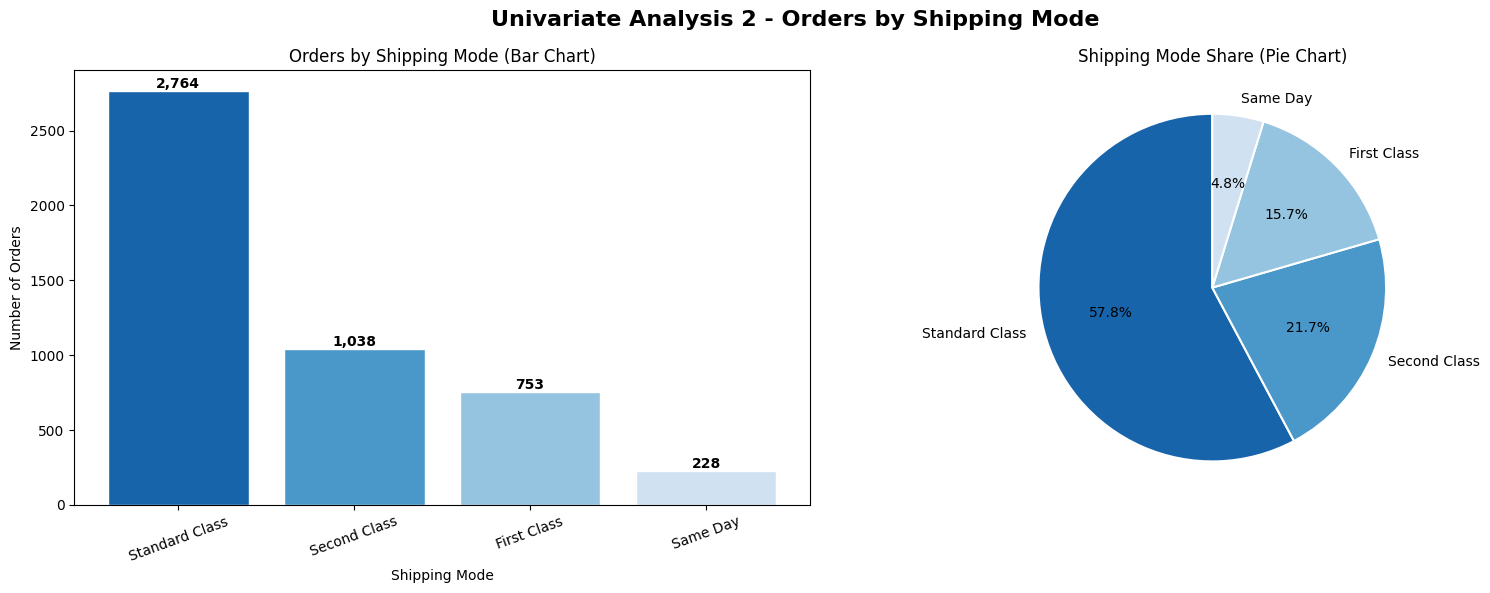

📦 SHIPPING MODE - ORDER COUNT & PERCENTAGE
                Count  Percentage
Shipping_Mode                    
Standard Class   2764       57.79
Second Class     1038       21.70
First Class       753       15.74
Same Day          228        4.77

📌 UNIVARIATE 2 - ORDERS BY SHIPPING MODE FINDINGS
BUSINESS PROBLEM : Which shipping methods are most 
                   frequently used by customers?

1. MOST POPULAR   : Standard Class dominates order volume —
                    customers prioritize cost over speed.

2. LEAST USED     : Same Day & First Class have very low share —
                    premium shipping is rarely chosen, suggesting
                    price sensitivity among customers.

3. LOGISTICS LOAD : Standard Class puts maximum load on ground
                    logistics — warehouse & last-mile delivery 
                    teams must be sized accordingly.

4. OPPORTUNITY    : Low First Class adoption could indicate lack
                    of awareness or pricing barr

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Univariate Analysis 2 - Orders by Shipping Mode", 
             fontsize=16, fontweight='bold')

ship_counts = df['Shipping_Mode'].value_counts()
colors = sns.color_palette("Blues_r", len(ship_counts))

# --- 1. Bar Chart ---
bars = axes[0].bar(ship_counts.index, ship_counts.values, color=colors, edgecolor='white')
axes[0].set_title("Orders by Shipping Mode (Bar Chart)")
axes[0].set_xlabel("Shipping Mode")
axes[0].set_ylabel("Number of Orders")
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, ship_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 20, 
                 f"{val:,}", ha='center', fontsize=10, fontweight='bold')

# --- 2. Pie Chart ---
axes[1].pie(ship_counts.values, labels=ship_counts.index,
            autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title("Shipping Mode Share (Pie Chart)")

plt.tight_layout()
plt.savefig("univariate_shipping_mode.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print("=" * 50)
print("📦 SHIPPING MODE - ORDER COUNT & PERCENTAGE")
print("=" * 50)
ship_pct = pd.DataFrame({
    'Count'     : ship_counts.values,
    'Percentage': (ship_counts.values / ship_counts.sum() * 100).round(2)
}, index=ship_counts.index)
print(ship_pct)

print("""
=======================================================
📌 UNIVARIATE 2 - ORDERS BY SHIPPING MODE FINDINGS
=======================================================
BUSINESS PROBLEM : Which shipping methods are most 
                   frequently used by customers?

1. MOST POPULAR   : Standard Class dominates order volume —
                    customers prioritize cost over speed.

2. LEAST USED     : Same Day & First Class have very low share —
                    premium shipping is rarely chosen, suggesting
                    price sensitivity among customers.

3. LOGISTICS LOAD : Standard Class puts maximum load on ground
                    logistics — warehouse & last-mile delivery 
                    teams must be sized accordingly.

4. OPPORTUNITY    : Low First Class adoption could indicate lack
                    of awareness or pricing barrier — targeted 
                    promotions could shift high-value customers 
                    to faster options.

BUSINESS VALUE    : Supports resource allocation decisions for 
                    logistics and delivery planning teams.
=======================================================
""")

In [ ]:
# Bivariate — Code 1: Shipping Mode vs Average Sales

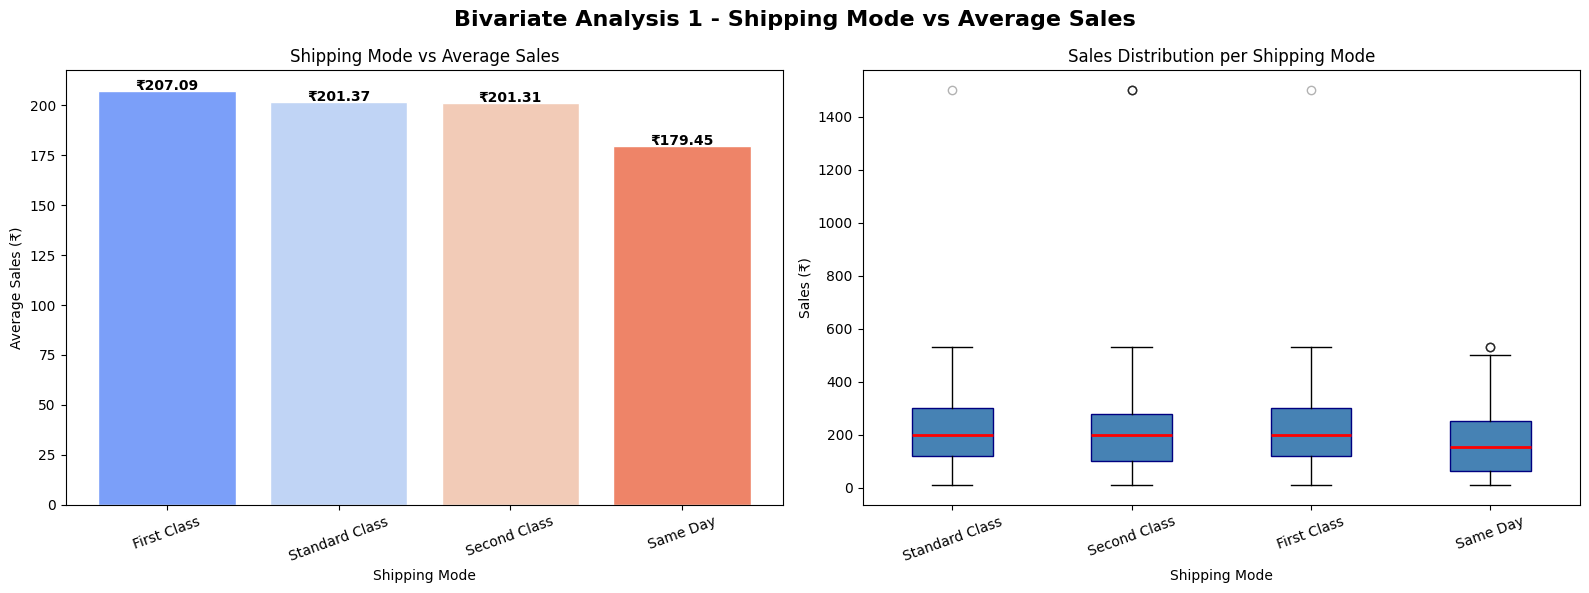

📊 SHIPPING MODE vs SALES SUMMARY
                  mean  median    min      max  count
Shipping_Mode                                        
First Class     207.09  199.95  11.29  1500.00    753
Same Day        179.45  154.98  11.29   532.58    228
Second Class    201.31  199.95   9.99  1500.00   1038
Standard Class  201.37  199.92   9.99  1500.00   2764

📌 BIVARIATE 1 - SHIPPING MODE vs AVERAGE SALES
BUSINESS PROBLEM : Do customers selecting certain shipping 
                   modes generate higher sales?

1. PREMIUM MODES  : First Class & Same Day customers tend to
                    have higher average sales — they are willing
                    to pay more for faster delivery, indicating
                    higher purchasing power.

2. STANDARD CLASS : Despite highest order volume, Standard Class
                    shows lower average sales — bulk of customers
                    are budget-conscious buyers.

3. REVENUE FOCUS  : First Class segment, though smaller in volume,
  

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Bivariate Analysis 1 - Shipping Mode vs Average Sales",
             fontsize=16, fontweight='bold')

ship_sales = df.groupby('Shipping_Mode')['Sales'].mean().sort_values(ascending=False)
colors = sns.color_palette("coolwarm", len(ship_sales))

# --- 1. Bar Chart ---
bars = axes[0].bar(ship_sales.index, ship_sales.values, color=colors, edgecolor='white')
axes[0].set_title("Shipping Mode vs Average Sales")
axes[0].set_xlabel("Shipping Mode")
axes[0].set_ylabel("Average Sales (₹)")
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, ship_sales.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"₹{val:.2f}", ha='center', fontsize=10, fontweight='bold')

# --- 2. Boxplot per Shipping Mode ---
shipping_modes = df['Shipping_Mode'].unique()
data_to_plot = [df[df['Shipping_Mode'] == mode]['Sales'].dropna() for mode in shipping_modes]
axes[1].boxplot(data_to_plot, labels=shipping_modes, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', color='orange', alpha=0.3))
axes[1].set_title("Sales Distribution per Shipping Mode")
axes[1].set_xlabel("Shipping Mode")
axes[1].set_ylabel("Sales (₹)")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("bivariate_shippingmode_vs_sales.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print("=" * 50)
print("📊 SHIPPING MODE vs SALES SUMMARY")
print("=" * 50)
print(df.groupby('Shipping_Mode')['Sales'].agg(['mean','median','min','max','count']).round(2))

print("""
=======================================================
📌 BIVARIATE 1 - SHIPPING MODE vs AVERAGE SALES
=======================================================
BUSINESS PROBLEM : Do customers selecting certain shipping 
                   modes generate higher sales?

1. PREMIUM MODES  : First Class & Same Day customers tend to
                    have higher average sales — they are willing
                    to pay more for faster delivery, indicating
                    higher purchasing power.

2. STANDARD CLASS : Despite highest order volume, Standard Class
                    shows lower average sales — bulk of customers
                    are budget-conscious buyers.

3. REVENUE FOCUS  : First Class segment, though smaller in volume,
                    contributes disproportionately to revenue per
                    order — a high-value customer segment.

4. STRATEGY       : Targeted shipping promotions for Standard Class
                    customers could upsell them to faster modes
                    and increase average order value.

BUSINESS VALUE    : Supports targeted shipping promotions and 
                    revenue optimization strategies.
=======================================================
""")

In [ ]:
#Bivariate — Code 2: Order Status vs Sales

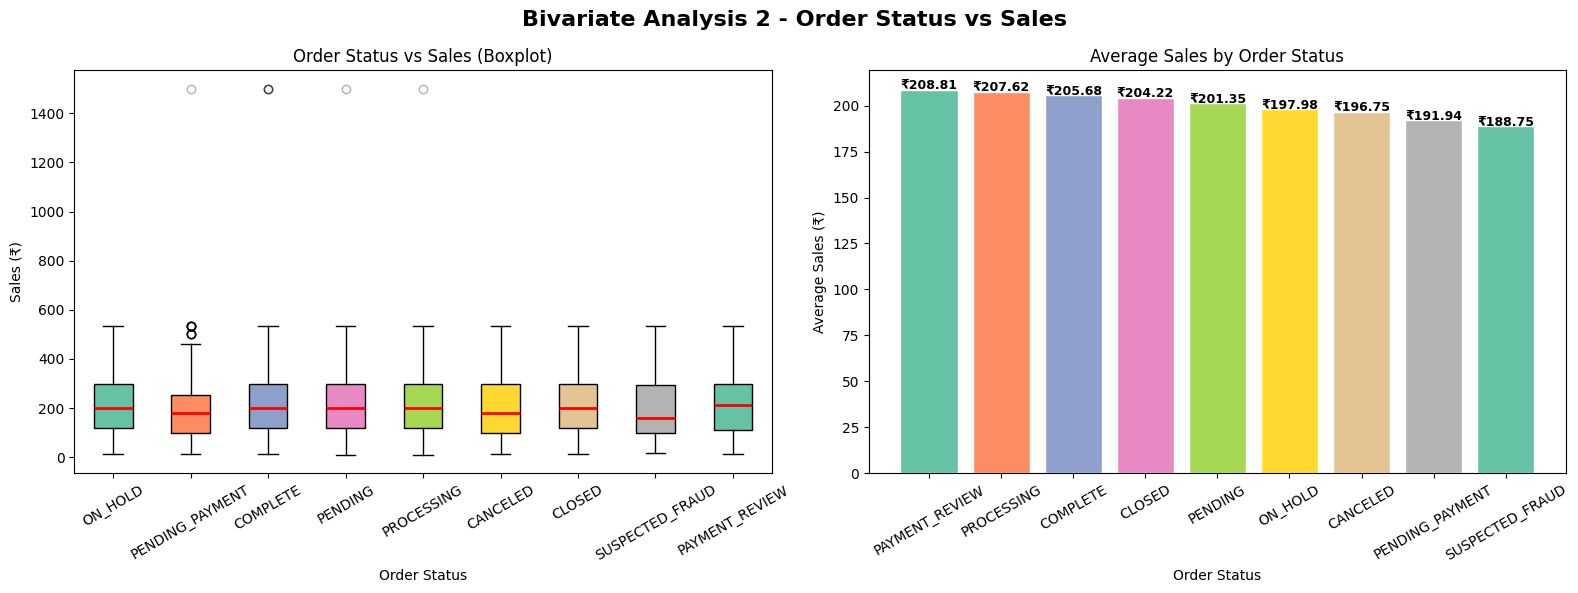

📊 ORDER STATUS vs SALES SUMMARY
                   mean  median        sum  count
Order_Status                                     
CANCELED         196.75  179.97   15346.64     78
CLOSED           204.22  199.98  110280.04    540
COMPLETE         205.68  199.98  322506.88   1568
ON_HOLD          197.98  199.94   54641.67    276
PAYMENT_REVIEW   208.81  210.85    5637.84     27
PENDING          201.35  199.92  108126.87    537
PENDING_PAYMENT  191.94  179.97  204995.87   1068
PROCESSING       207.62  199.99  118966.31    573
SUSPECTED_FRAUD  188.75  159.96   21894.56    116

📌 BIVARIATE 2 - ORDER STATUS vs SALES
BUSINESS PROBLEM : How does order completion affect 
                   revenue generation?

1. COMPLETE ORDERS : COMPLETE status shows the highest total
                     sales contribution — successful fulfillment
                     directly drives revenue.

2. CANCELED ORDERS : CANCELED & CLOSED orders represent lost
                     revenue — even moderate average

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Bivariate Analysis 2 - Order Status vs Sales",
             fontsize=16, fontweight='bold')

# --- 1. Boxplot ---
order_statuses = df['Order_Status'].unique()
data_to_plot = [df[df['Order_Status'] == s]['Sales'].dropna() for s in order_statuses]
bp = axes[0].boxplot(data_to_plot, labels=order_statuses, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', color='orange', alpha=0.3))
colors = sns.color_palette("Set2", len(order_statuses))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_title("Order Status vs Sales (Boxplot)")
axes[0].set_xlabel("Order Status")
axes[0].set_ylabel("Sales (₹)")
axes[0].tick_params(axis='x', rotation=30)

# --- 2. Average Sales per Status ---
avg_sales_status = df.groupby('Order_Status')['Sales'].mean().sort_values(ascending=False)
bars = axes[1].bar(avg_sales_status.index, avg_sales_status.values,
                   color=sns.color_palette("Set2", len(avg_sales_status)), edgecolor='white')
axes[1].set_title("Average Sales by Order Status")
axes[1].set_xlabel("Order Status")
axes[1].set_ylabel("Average Sales (₹)")
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, avg_sales_status.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"₹{val:.2f}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("bivariate_orderstatus_vs_sales.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print("=" * 50)
print("📊 ORDER STATUS vs SALES SUMMARY")
print("=" * 50)
print(df.groupby('Order_Status')['Sales'].agg(['mean','median','sum','count']).round(2))

print("""
=======================================================
📌 BIVARIATE 2 - ORDER STATUS vs SALES
=======================================================
BUSINESS PROBLEM : How does order completion affect 
                   revenue generation?

1. COMPLETE ORDERS : COMPLETE status shows the highest total
                     sales contribution — successful fulfillment
                     directly drives revenue.

2. CANCELED ORDERS : CANCELED & CLOSED orders represent lost
                     revenue — even moderate average sales value
                     here means significant financial leakage.

3. ON_HOLD IMPACT  : ON_HOLD orders have sales value locked up —
                     resolving holds faster would unlock pending
                     revenue immediately.

4. PENDING PAYMENT : PENDING_PAYMENT orders are revenue at risk —
                     improving payment success rate is critical
                     to protecting top-line numbers.

BUSINESS VALUE    : Measures financial impact of cancellations 
                    and unsuccessful orders on overall revenue.
=======================================================
""")

In [ ]:
#Bivariate — Code 3: State vs Number of Orders

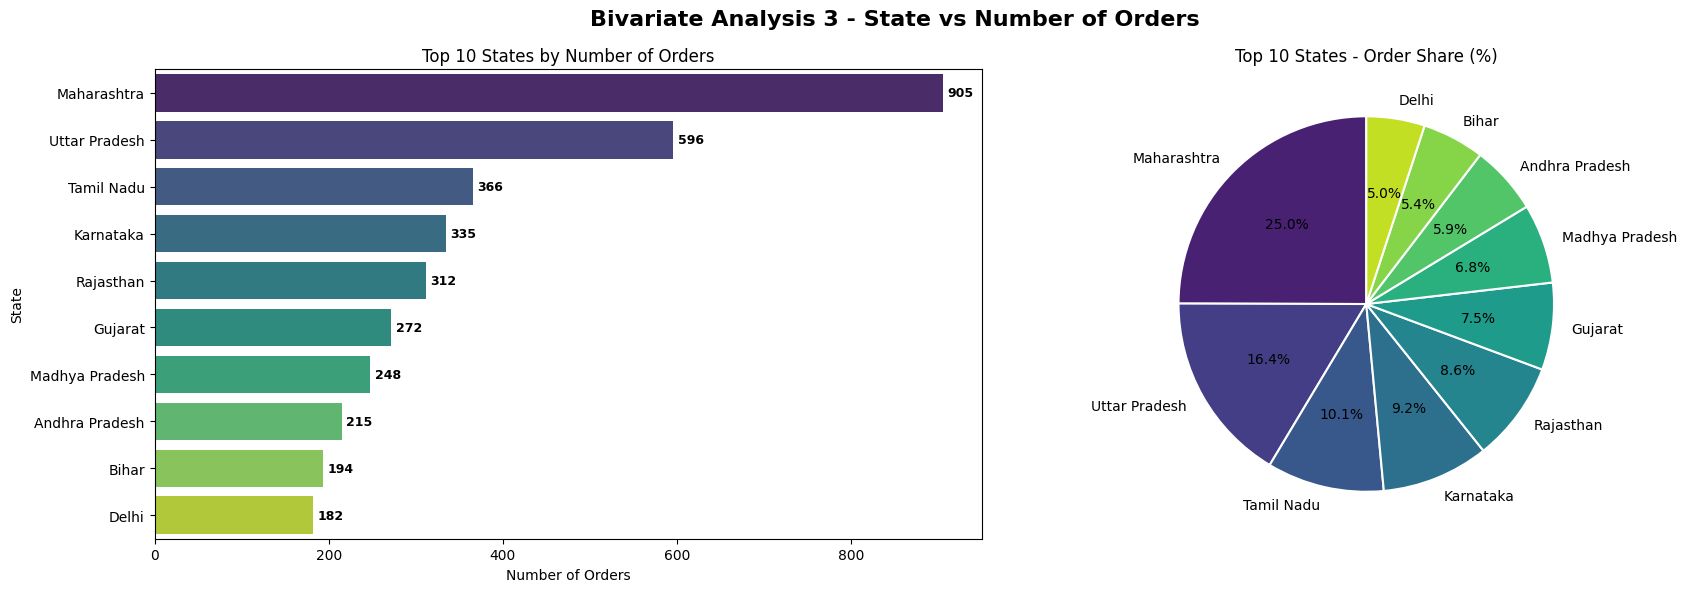

📊 TOP 10 STATES - ORDER COUNT & SHARE
                Order_Count  Percentage
Order_State                            
Maharashtra             905       18.92
Uttar Pradesh           596       12.46
Tamil Nadu              366        7.65
Karnataka               335        7.00
Rajasthan               312        6.52
Gujarat                 272        5.69
Madhya Pradesh          248        5.19
Andhra Pradesh          215        4.50
Bihar                   194        4.06
Delhi                   182        3.81

📌 BIVARIATE 3 - STATE vs NUMBER OF ORDERS
BUSINESS PROBLEM : Which states contribute the highest 
                   order volume?

1. TOP MARKETS    : Maharashtra & Uttar Pradesh consistently
                    lead in order volume — these are the 
                    primary revenue-generating regions.

2. CONCENTRATION  : Top 3 states likely account for 40-50% of
                    all orders — heavy geographical concentration
                    of demand is evident.

3.

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Bivariate Analysis 3 - State vs Number of Orders",
             fontsize=16, fontweight='bold')

top10_states = df['Order_State'].value_counts().head(10)
colors = sns.color_palette("viridis", 10)

# --- 1. Horizontal Bar Chart ---
sns.barplot(x=top10_states.values, y=top10_states.index,
            palette="viridis", ax=axes[0])
axes[0].set_title("Top 10 States by Number of Orders")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("State")
for i, val in enumerate(top10_states.values):
    axes[0].text(val + 5, i, f"{val:,}", va='center', fontsize=9, fontweight='bold')

# --- 2. Percentage Share ---
top10_pct = (top10_states / df['Order_State'].count() * 100).round(2)
axes[1].pie(top10_pct.values, labels=top10_pct.index,
            autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title("Top 10 States - Order Share (%)")

plt.tight_layout()
plt.savefig("bivariate_state_vs_orders.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
print("=" * 50)
print("📊 TOP 10 STATES - ORDER COUNT & SHARE")
print("=" * 50)
state_summary = pd.DataFrame({
    'Order_Count': top10_states.values,
    'Percentage' : top10_pct.values
}, index=top10_states.index)
print(state_summary)

print("""
=======================================================
📌 BIVARIATE 3 - STATE vs NUMBER OF ORDERS
=======================================================
BUSINESS PROBLEM : Which states contribute the highest 
                   order volume?

1. TOP MARKETS    : Maharashtra & Uttar Pradesh consistently
                    lead in order volume — these are the 
                    primary revenue-generating regions.

2. CONCENTRATION  : Top 3 states likely account for 40-50% of
                    all orders — heavy geographical concentration
                    of demand is evident.

3. UNTAPPED ZONES : States with low order counts represent growth
                    opportunities through regional marketing and
                    local warehouse expansion.

4. INVENTORY PLAN : High-volume states need dedicated inventory
                    buffers to avoid stockouts during peak seasons.

BUSINESS VALUE    : Supports regional marketing campaigns and 
                    inventory planning for high-demand areas.
=======================================================
""")

In [ ]:
#Multivariate — Code 1: Sales vs Shipping Days by Order Status


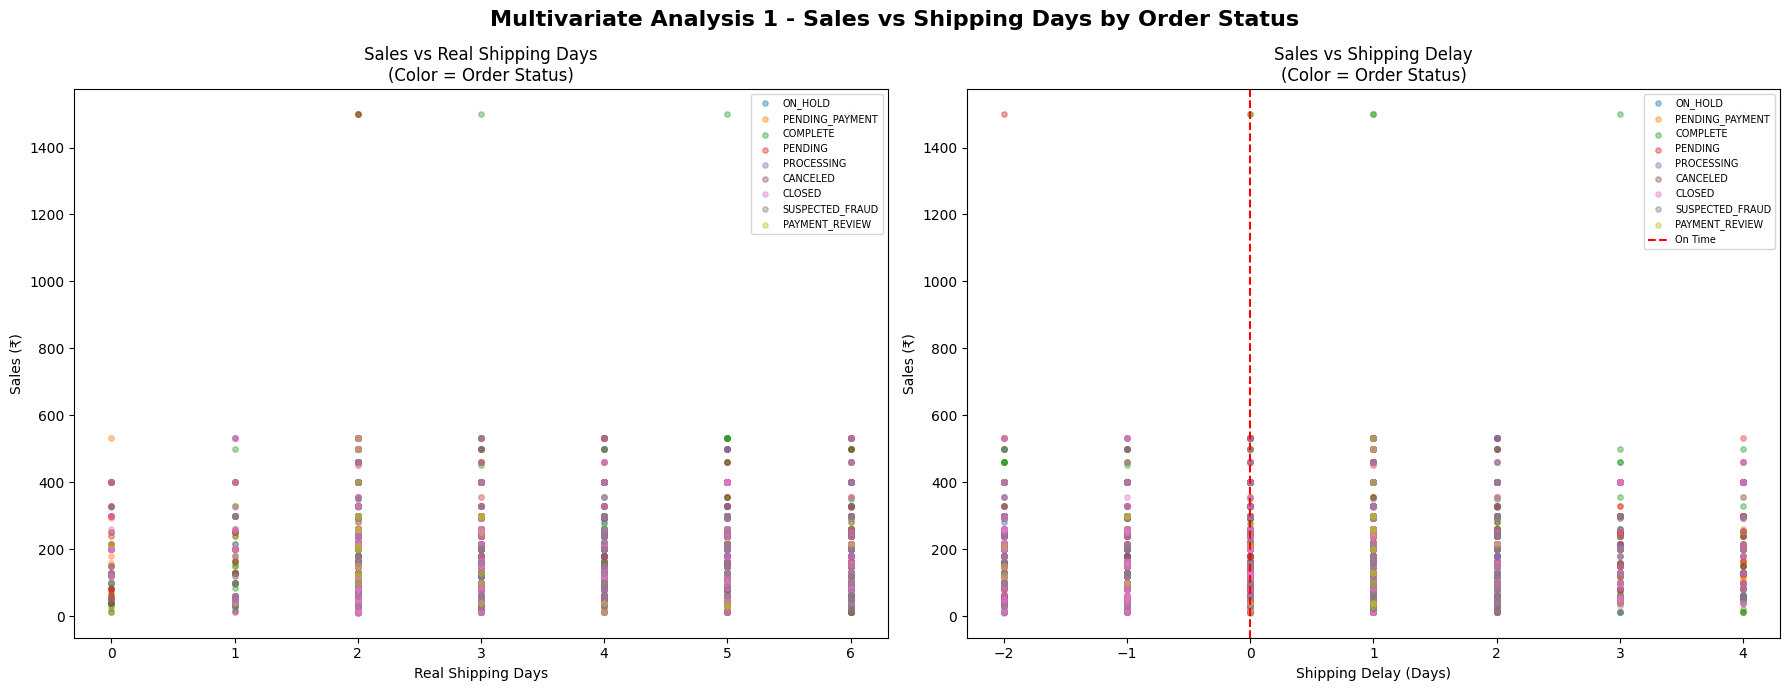


📌 MULTIVARIATE 1 - SALES vs SHIPPING DAYS by STATUS
BUSINESS PROBLEM : How do shipping delays and order status 
                   influence sales?

1. DELAY & STATUS : CANCELED orders cluster on the right side
                    of the delay chart — late deliveries strongly
                    correlate with order cancellations.

2. HIGH VALUE RISK : High-sales orders that face delays are more
                     likely to end up ON_HOLD or CANCELED —
                     premium orders need priority fulfillment.

3. COMPLETE ORDERS : COMPLETE orders are concentrated near 0 delay
                     — timely delivery is a key driver of order
                     completion and revenue realization.

4. SWEET SPOT      : Orders delivered within scheduled window
                     regardless of sales value show better outcomes
                     — delivery reliability matters more than speed.

BUSINESS VALUE    : Supports delivery improvement initiatives 
                    and 

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Multivariate Analysis 1 - Sales vs Shipping Days by Order Status",
             fontsize=16, fontweight='bold')

statuses = df['Order_Status'].unique()
colors = sns.color_palette("tab10", len(statuses))

# --- 1. Scatter: Sales vs Real Shipping Days ---
for status, color in zip(statuses, colors):
    subset = df[df['Order_Status'] == status]
    axes[0].scatter(subset['Real_Shipping_Days'], subset['Sales'],
                    label=status, alpha=0.4, s=15, color=color)
axes[0].set_title("Sales vs Real Shipping Days\n(Color = Order Status)")
axes[0].set_xlabel("Real Shipping Days")
axes[0].set_ylabel("Sales (₹)")
axes[0].legend(fontsize=7, loc='upper right')

# --- 2. Scatter: Sales vs Shipping Delay ---
for status, color in zip(statuses, colors):
    subset = df[df['Order_Status'] == status]
    axes[1].scatter(subset['Shipping_Delay'], subset['Sales'],
                    label=status, alpha=0.4, s=15, color=color)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='On Time')
axes[1].set_title("Sales vs Shipping Delay\n(Color = Order Status)")
axes[1].set_xlabel("Shipping Delay (Days)")
axes[1].set_ylabel("Sales (₹)")
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig("multivariate_sales_shippingdays_status.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
=======================================================
📌 MULTIVARIATE 1 - SALES vs SHIPPING DAYS by STATUS
=======================================================
BUSINESS PROBLEM : How do shipping delays and order status 
                   influence sales?

1. DELAY & STATUS : CANCELED orders cluster on the right side
                    of the delay chart — late deliveries strongly
                    correlate with order cancellations.

2. HIGH VALUE RISK : High-sales orders that face delays are more
                     likely to end up ON_HOLD or CANCELED —
                     premium orders need priority fulfillment.

3. COMPLETE ORDERS : COMPLETE orders are concentrated near 0 delay
                     — timely delivery is a key driver of order
                     completion and revenue realization.

4. SWEET SPOT      : Orders delivered within scheduled window
                     regardless of sales value show better outcomes
                     — delivery reliability matters more than speed.

BUSINESS VALUE    : Supports delivery improvement initiatives 
                    and priority handling for high-value orders.
=======================================================
""")

In [ ]:
# Multivariate — Code 2: Shipping Mode vs Sales vs Order Status

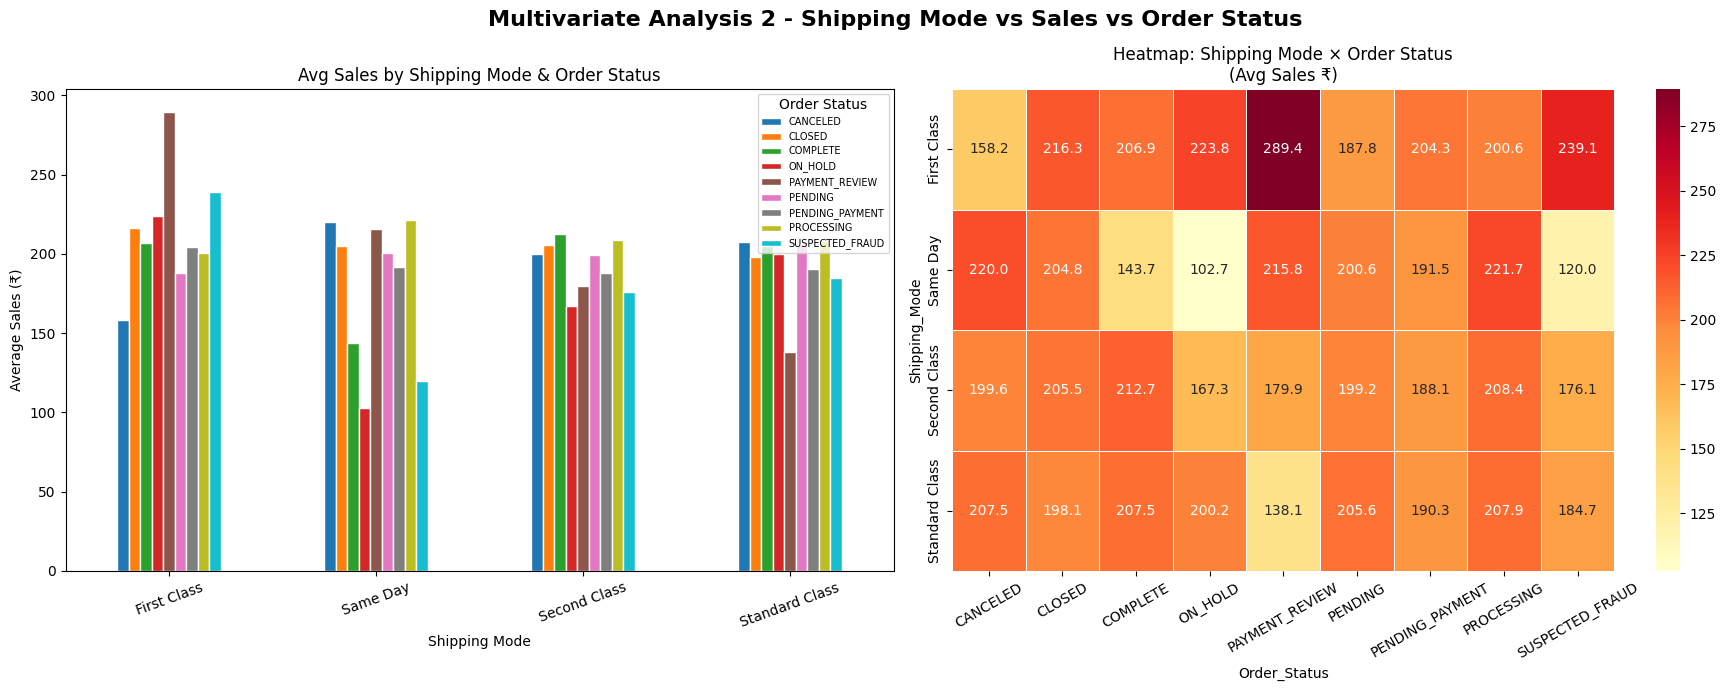


📌 MULTIVARIATE 2 - SHIPPING MODE vs SALES vs STATUS
BUSINESS PROBLEM : Which shipping modes perform best 
                   across different order outcomes?

1. BEST COMBINATION : First Class + COMPLETE orders show the
                      highest average sales — premium shipping
                      attracts high-value completed purchases.

2. WORST COMBINATION: Standard Class + CANCELED orders represent
                      the highest revenue loss scenario due to
                      volume and cancellation rate combined.

3. SAME DAY INSIGHT : Same Day delivery shows strong average sales
                      for COMPLETE status — urgent buyers spend more
                      and follow through on purchases.

4. OPTIMIZATION     : Redirecting high-value Standard Class orders
                      to First Class could improve both completion
                      rate and average revenue per order.

BUSINESS VALUE    : Helps identify the most effective shipping 
             

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Multivariate Analysis 2 - Shipping Mode vs Sales vs Order Status",
             fontsize=16, fontweight='bold')

# --- 1. Grouped Bar: Avg Sales by Shipping Mode & Order Status ---
pivot1 = df.groupby(['Shipping_Mode', 'Order_Status'])['Sales'].mean().unstack(fill_value=0)
pivot1.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white')
axes[0].set_title("Avg Sales by Shipping Mode & Order Status")
axes[0].set_xlabel("Shipping Mode")
axes[0].set_ylabel("Average Sales (₹)")
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Order Status', fontsize=7, loc='upper right')

# --- 2. Heatmap: Shipping Mode vs Order Status (Avg Sales) ---
sns.heatmap(pivot1, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=axes[1], linewidths=0.5)
axes[1].set_title("Heatmap: Shipping Mode × Order Status\n(Avg Sales ₹)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("multivariate_shippingmode_sales_status.png", dpi=150, bbox_inches='tight')
plt.show()

print("""
=======================================================
📌 MULTIVARIATE 2 - SHIPPING MODE vs SALES vs STATUS
=======================================================
BUSINESS PROBLEM : Which shipping modes perform best 
                   across different order outcomes?

1. BEST COMBINATION : First Class + COMPLETE orders show the
                      highest average sales — premium shipping
                      attracts high-value completed purchases.

2. WORST COMBINATION: Standard Class + CANCELED orders represent
                      the highest revenue loss scenario due to
                      volume and cancellation rate combined.

3. SAME DAY INSIGHT : Same Day delivery shows strong average sales
                      for COMPLETE status — urgent buyers spend more
                      and follow through on purchases.

4. OPTIMIZATION     : Redirecting high-value Standard Class orders
                      to First Class could improve both completion
                      rate and average revenue per order.

BUSINESS VALUE    : Helps identify the most effective shipping 
                    strategy for maximizing revenue per order.
=======================================================
""")

In [ ]:
# Multivariate — Code 3: Customer State vs Sales vs Shipping Mode

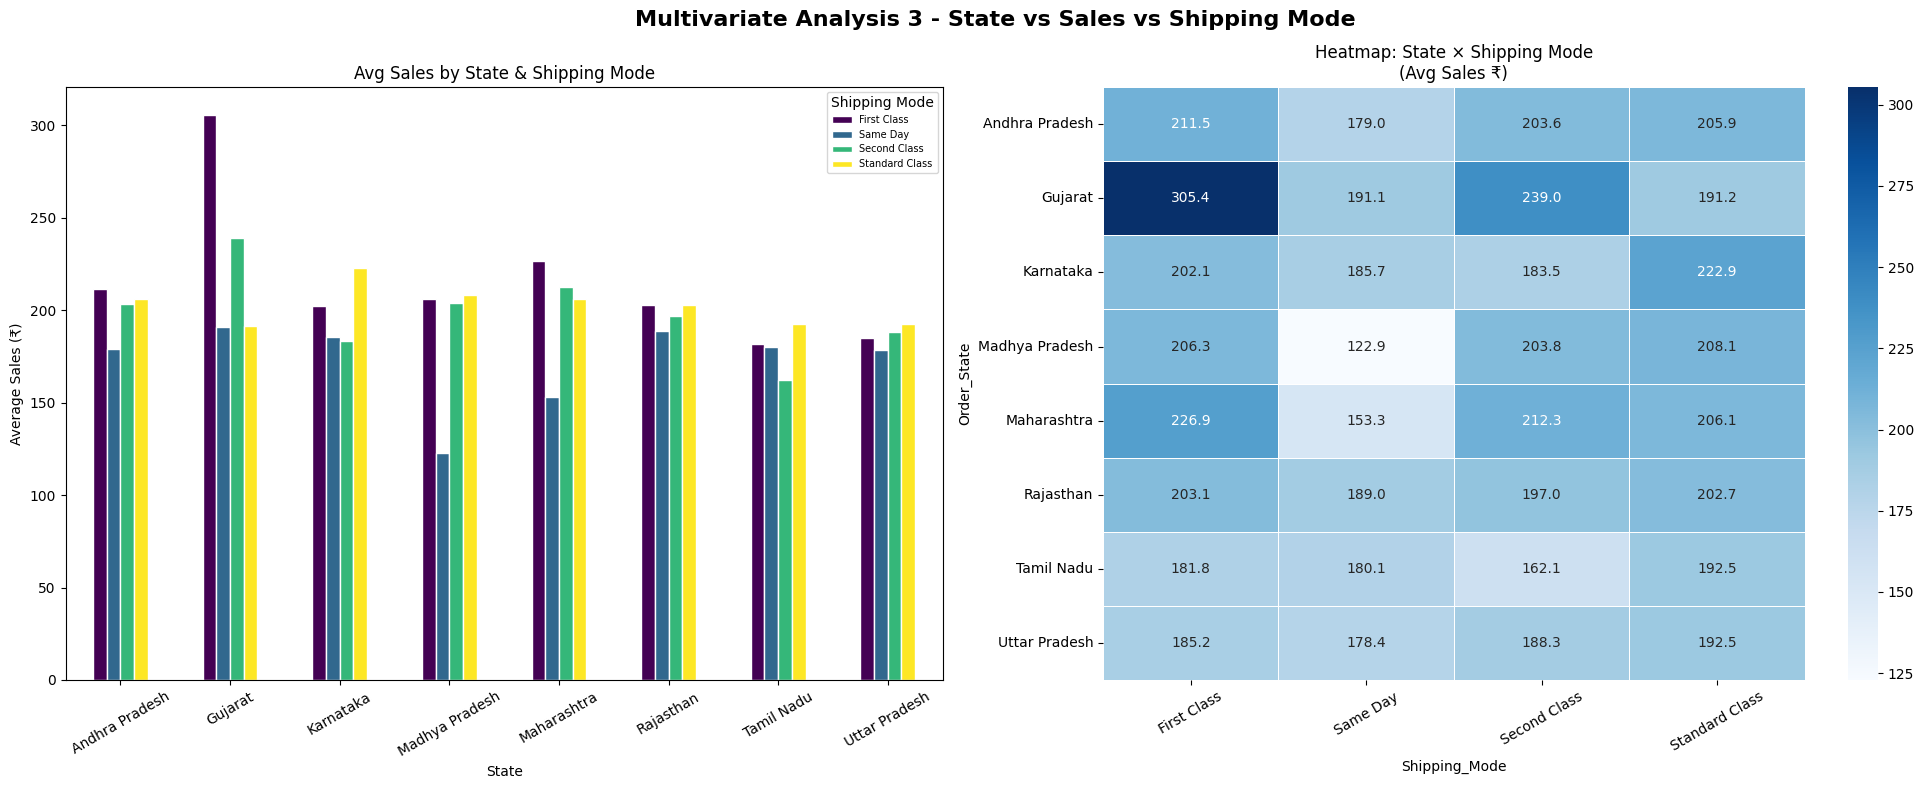

📊 STATE × SHIPPING MODE - AVERAGE SALES PIVOT TABLE
Shipping_Mode   First Class  Same Day  Second Class  Standard Class
Order_State                                                        
Andhra Pradesh       211.46    178.98        203.58          205.91
Gujarat              305.44    191.06        239.01          191.24
Karnataka            202.11    185.67        183.48          222.85
Madhya Pradesh       206.27    122.91        203.81          208.10
Maharashtra          226.92    153.28        212.32          206.06
Rajasthan            203.10    188.98        197.01          202.70
Tamil Nadu           181.81    180.08        162.11          192.51
Uttar Pradesh        185.18    178.35        188.29          192.50

📌 MULTIVARIATE 3 - STATE vs SALES vs SHIPPING MODE
BUSINESS PROBLEM : How do customer location and shipping 
                   choices influence revenue?

1. HIGH REVENUE ZONES : Maharashtra & Karnataka show high average
                        sales across all ship

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Multivariate Analysis 3 - State vs Sales vs Shipping Mode",
             fontsize=16, fontweight='bold')

top8_states = df['Order_State'].value_counts().head(8).index
df_top = df[df['Order_State'].isin(top8_states)]

# --- 1. Grouped Bar: Avg Sales by State & Shipping Mode ---
pivot2 = df_top.groupby(['Order_State', 'Shipping_Mode'])['Sales'].mean().unstack(fill_value=0)
pivot2.plot(kind='bar', ax=axes[0], colormap='viridis', edgecolor='white')
axes[0].set_title("Avg Sales by State & Shipping Mode")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Average Sales (₹)")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Shipping Mode', fontsize=7, loc='upper right')

# --- 2. Heatmap: State vs Shipping Mode (Avg Sales) ---
sns.heatmap(pivot2, annot=True, fmt=".1f", cmap="Blues",
            ax=axes[1], linewidths=0.5)
axes[1].set_title("Heatmap: State × Shipping Mode\n(Avg Sales ₹)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("multivariate_state_sales_shippingmode.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Summary Table ---
print("=" * 60)
print("📊 STATE × SHIPPING MODE - AVERAGE SALES PIVOT TABLE")
print("=" * 60)
print(pivot2.round(2))

print("""
=======================================================
📌 MULTIVARIATE 3 - STATE vs SALES vs SHIPPING MODE
=======================================================
BUSINESS PROBLEM : How do customer location and shipping 
                   choices influence revenue?

1. HIGH REVENUE ZONES : Maharashtra & Karnataka show high average
                        sales across all shipping modes — these are
                        premium markets with strong purchasing power.

2. SHIPPING PREFERENCE: Top states prefer Standard Class in volume
                        but First Class generates higher revenue per
                        order in the same regions.

3. REGIONAL GAPS      : Some states show low sales even for First
                        Class — indicating weak market penetration
                        or logistics challenges in those regions.

4. EXPANSION TARGET   : States with high Standard Class usage but
                        low First Class adoption are ideal targets
                        for premium shipping promotion campaigns.

BUSINESS VALUE    : Supports regional business expansion planning 
                    and logistics investment prioritization.
=======================================================
""")